In [47]:
# Import relevant libraries for the classification task. 
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.neural_network import MLPClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm


from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedShuffleSplit, RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, QuantileTransformer, RobustScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, classification_report, make_scorer, confusion_matrix
from sklearn.feature_selection import  SelectKBest, f_classif, SelectPercentile

from collections import Counter

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier


Preprocess

In [2]:
# import the dataset

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
default_of_credit_card_clients = fetch_ucirepo(id=350) 
  
# data (as pandas dataframes) 
X = default_of_credit_card_clients.data.features 
y = default_of_credit_card_clients.data.targets 
  
# metadata 
print(default_of_credit_card_clients.metadata) 
  
# variable information 
print(default_of_credit_card_clients.variables) 

display(X)

# Map default column names to more descriptive names.
# Create a mapping dictionary for column names.
column_mapping = {
    'X1': 'LIMIT_BAL',
    'X2': 'SEX',
    'X3': 'EDUCATION',
    'X4': 'MARRIAGE',
    'X5': 'AGE',
    'X6': 'PAY_0',
    'X7': 'PAY_2',
    'X8': 'PAY_3',
    'X9': 'PAY_4',
    'X10': 'PAY_5',
    'X11': 'PAY_6',
    'X12': 'BILL_AMT1',
    'X13': 'BILL_AMT2',
    'X14': 'BILL_AMT3',
    'X15': 'BILL_AMT4',
    'X16': 'BILL_AMT5',
    'X17': 'BILL_AMT6',
    'X18': 'PAY_AMT1',
    'X19': 'PAY_AMT2',
    'X20': 'PAY_AMT3',
    'X21': 'PAY_AMT4',
    'X22': 'PAY_AMT5',
    'X23': 'PAY_AMT6'
}

# and the inverse mapping
inverse_mapping = {v: k for k, v in column_mapping.items()}

# Rename the columns in the dataframe
X = X.rename(columns=column_mapping)

# full dataset
X_complete = X.copy()
X_complete['target'] = y
X_complete

{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,3502,8979,5190,0,1837,3526,8998,129,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,2758,20878,20582,19357,0,0,22000,4200,2000,3100
29998,80000,1,3,1,41,1,-1,0,0,0,...,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,1,3,1,41,1,-1,0,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [18]:
Counter(y_test)

Counter({0: 4673, 1: 1327})

In [27]:
from sklearn.utils.class_weight import compute_class_weight

# calculate class weights based on the training data
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights

array([0.64202022, 2.26031268])

In [63]:
X_complete.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'target'],
      dtype='object')

In [ ]:
col = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
col = ['BILL_AMT1', 'LIMIT_BAL', 'PAY_0']

----------------------------------------------------------------------------------------------------
Trained on 24000 samples and tested on 6000 samples


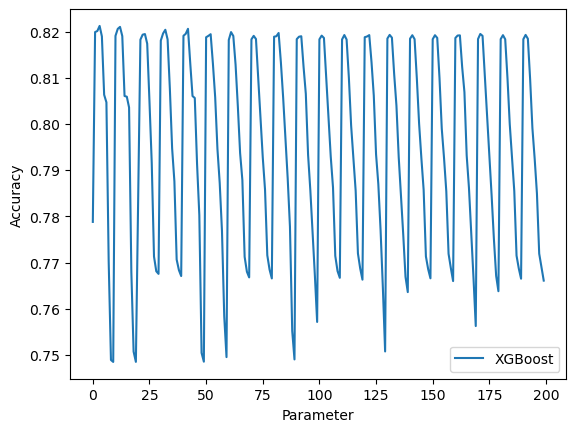

XGBoost best parameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'classifier__scale_pos_weight': 3.6222222222222222}
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      4673
           1       0.48      0.58      0.52      1327

    accuracy                           0.77      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.79      0.77      0.77      6000

XGBoost ROC AUC score: 0.6995568991227482
----------------------------------------------------------------------------------------------------
Trained on 24000 samples and tested on 6000 samples


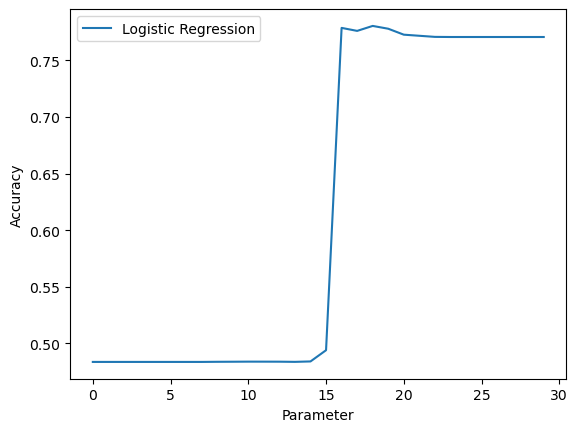

Logistic Regression best parameters: {'classifier__C': 0.3290344562312671}
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      4673
           1       0.47      0.53      0.50      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.68      0.67      6000
weighted avg       0.78      0.76      0.77      6000

Logistic Regression ROC AUC score: 0.6820808050738332
----------------------------------------------------------------------------------------------------
Trained on 24000 samples and tested on 6000 samples


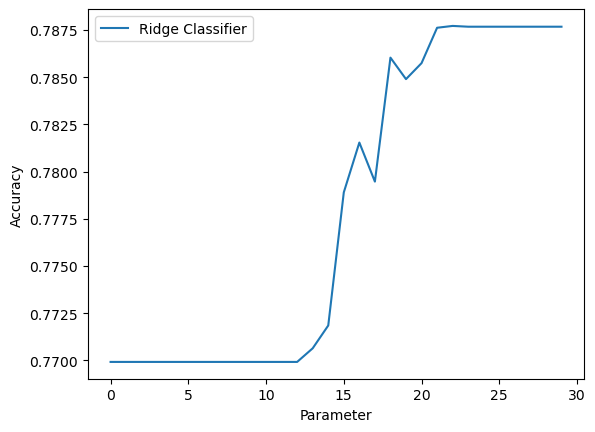

Ridge Classifier best parameters: {'classifier__alpha': 7880462.815669936}
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      4673
           1       0.50      0.51      0.50      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.68      0.68      6000
weighted avg       0.78      0.78      0.78      6000

Ridge Classifier ROC AUC score: 0.680928100968365
----------------------------------------------------------------------------------------------------
Trained on 24000 samples and tested on 6000 samples


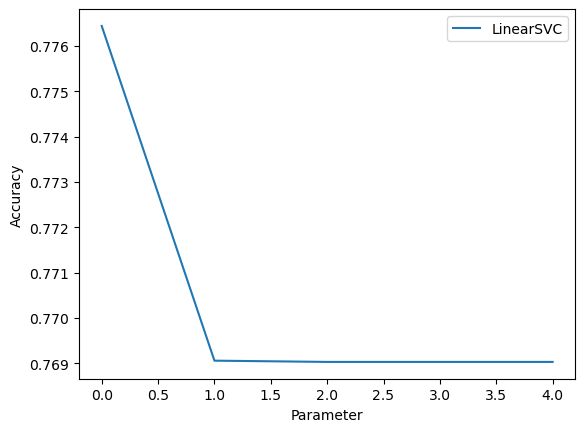

LinearSVC best parameters: {'classifier__C': 0.01}
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      4673
           1       0.47      0.53      0.50      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.68      0.67      6000
weighted avg       0.78      0.76      0.77      6000

LinearSVC ROC AUC score: 0.6821878027198849
----------------------------------------------------------------------------------------------------
Trained on 24000 samples and tested on 6000 samples


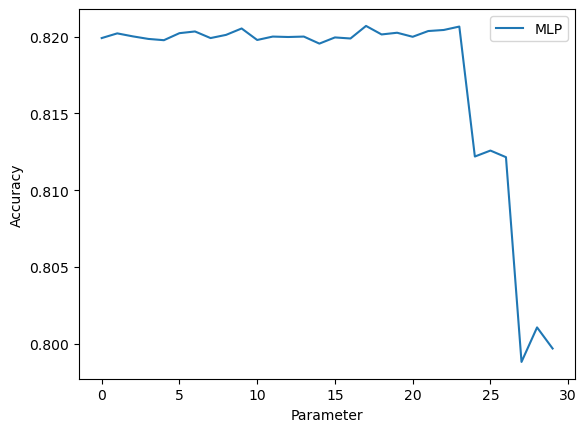

MLP best parameters: {'classifier__alpha': 0.46415888336127775, 'classifier__hidden_layer_sizes': (12, 8), 'classifier__learning_rate': 'adaptive'}
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.64      0.38      0.48      1327

    accuracy                           0.82      6000
   macro avg       0.74      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000

MLP ROC AUC score: 0.6614498527754319


In [67]:
classifiers = {'XGBoost': XGBClassifier(objective='binary:logistic', eval_metric='logloss', scale_pos_weight = 99),
               'Logistic Regression': LogisticRegression(class_weight='balanced', solver='liblinear'),
               'Ridge Classifier': RidgeClassifier(class_weight='balanced'),
               'LinearSVC': LinearSVC(class_weight='balanced', max_iter=5000, dual = 'auto'),
               'MLP': MLPClassifier(learning_rate='adaptive', max_iter=7000, solver='adam', activation='relu')
               }

accuracy_scores = []

# Load the data for each subjectLRL

X = X_complete.drop(columns=['target']).copy()
#X = X[col]
y = X_complete['target'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

# -- Train and test the classifiers --
grid_classifier = [] # Store the grid classifier for each subject

# pca components
max_features = 33
for classifier_idx, (name, classifier) in enumerate(classifiers.items()):
    print(f'-' * 100)
    print(f'Trained on {len(y_train)} samples and tested on {len(y_test)} samples')

    # define the scoring functions
    accuracy_scorer = make_scorer(accuracy_score)
    precision_scorer = make_scorer(precision_score)
    recall_scorer = make_scorer(recall_score)
    f1_scorer = make_scorer(f1_score)
    roc_auc_scorer = make_scorer(roc_auc_score)

    scoring = {
        'accuracy': accuracy_scorer,
        'roc_auc': roc_auc_scorer,
        'f1': f1_scorer
    }

    pipeline = Pipeline([
        ('feature_selection', SelectPercentile(f_classif, percentile=15)),
        ('scaler', StandardScaler()),
        #('robustscaler', RobustScaler()),
        #('pca', PCA(n_components=5)),
        ('classifier', classifier)
    ])

    # Define the parameter grid for the classifiers
    if name == 'Logistic Regression':
        param_grid = {
            #'pca__n_components': [i for i in range(2, int(max_features/2))],
            #'pca__n_components': [i for i in range(2, 10)],
            #'classifier__C': np.linspace(1.0, 2.0, 10)#,
            'classifier__C': np.logspace(-10, 2, 30)
        }
    
    elif name == 'Ridge Classifier':
        param_grid = {
            #'pca__n_components': [i for i in range(2, int(max_features/2))],
            #'pca__n_components': [i for i in range(2, 10)],
            'classifier__alpha': np.logspace(-5, 10, 30)
        }

    elif name == 'LinearSVC':
        param_grid = {
        #'pca__n_components': [i for i in range(2, 10)],
        'classifier__C': np.logspace(-4, 4, 5), # C values from 2^-3 to 2^10
    }
    elif name == 'MLP':
        param_grid = {
            #'pca__n_components': [i for i in range(2, int(max_features/2))],
            #'pca__n_components': [i for i in range(2, 10)],
            'classifier__hidden_layer_sizes': [(12,8), (20,14), (28, 20)],
            'classifier__alpha': np.logspace(-3, 1, 10),
            'classifier__learning_rate': ['adaptive']
        }
    elif name == 'XGBoost':
        param_grid = {
            'classifier__n_estimators': [100, 200], # Number of trees
            'classifier__learning_rate': np.linspace(0.01, 0.1, 5), # Step size shrinkage
            'classifier__max_depth': [3, 5],        # Max depth of a tree
            'classifier__scale_pos_weight': np.linspace(0.6, 4.0, 10)
        }

    
    # define the grid search
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)
    #grid = GridSearchCV(SVC(), param_grid=param_grid, cv=cv)
    grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring=scoring, refit='roc_auc', n_jobs=-1)

    # fit the grid search
    grid.fit(X_train, y_train)

    grid_classifier.append(grid)

    # -- Plotting mean accuracy of the current classifier parameter iteration i.e. rows of cv_results_ ---
    plt.plot(np.arange(len(grid.cv_results_['mean_test_accuracy'])), grid.cv_results_['mean_test_accuracy'], label=name)
    plt.xlabel('Parameter')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # --- Make classification report ---
    y_pred = grid.best_estimator_.predict(X_test)
    print(f'{name} best parameters: {grid.best_params_}')
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # print ROC AUC score 
    print(f'{name} ROC AUC score: {roc_auc_score(y_test, y_pred)}')

    